# Manifold Learning via Denoising Autoencoders

**DLAI 2025/2026 — Sapienza University of Rome**

This notebook reproduces the complete experimental workflow:

1. **Dataset Generation**: Swiss Roll (2D manifold in R³) and Linear H₃,₃₀
2. **Model Training**: DAE and VAE with different noise configurations
3. **Representation Quality**: Topology metrics (trustworthiness, continuity)
4. **Dimension Estimation**: Minkowski (box-counting) and geometric-probabilistic methods
5. **Comparative Analysis**: DAE vs VAE latent geometry

**Runtime**: ~5-10 minutes on CPU

---
## Setup & Imports

In [106]:
pip install torch torchvision numpy scipy scikit-learn matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [107]:
import os
import sys
import numpy as np
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

# Make sure we can import from parent directory
sys.path.insert(0, '..')

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)

Device: cpu


In [108]:
# Import project modules
from data.datasets import get_dataset
from data.noise import get_noise_fn
from models.autoencoder import build_dae
from models.vae import build_vae
from models.losses import dae_loss, vae_loss
from dimension_estimation.minkowski import minkowski_dimension
from dimension_estimation.geometric_prob import estimate_dimension
from evaluation.topology import evaluate_topology

print("✓ All modules imported successfully")

✓ All modules imported successfully


---
## 1. Dataset Generation

We work with three datasets:
- **Swiss Roll**: 2D manifold embedded in R³ (classic test case)
- **Linear H₃,₃₀**: 3D hypercube embedded in R³⁰ via orthonormal projection
- **MINST**: standard machine learning benchmark consisting of 70,000 grayscale images of handwritten digits (0–9). We will be using one MNIST digits as the dataset (choose freely) to ensure a much better manifold structure.

We will begin by generating the synthetic datasets first:

In [109]:
# Swiss Roll
swiss_roll = get_dataset("swiss_roll", n_samples=10000, noise=0.0)
X_swiss = swiss_roll.data.numpy()
color_swiss = swiss_roll.labels

print(f"Swiss Roll: {X_swiss.shape}")
print(f"  Intrinsic dimension: 2 (ground truth)")

# Linear manifold H₃,₃₀
linear_h = get_dataset("linear", n_samples=10000, intrinsic_dim=3, ambient_dim=30)
X_linear = linear_h.data.numpy()

print(f"\nLinear H₃,₃₀: {X_linear.shape}")
print(f"  Intrinsic dimension: 3 (ground truth)")

Swiss Roll: (10000, 3)
  Intrinsic dimension: 2 (ground truth)

Linear H₃,₃₀: (10000, 30)
  Intrinsic dimension: 3 (ground truth)


<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
C:\Users\monin\AppData\Local\Temp\ipykernel_32728\2873393952.py:6: SyntaxWarning: invalid escape sequence '\m'
  ax.set_title('Swiss Roll in $\mathbb{R}^3$ (2D manifold)', fontsize=14)


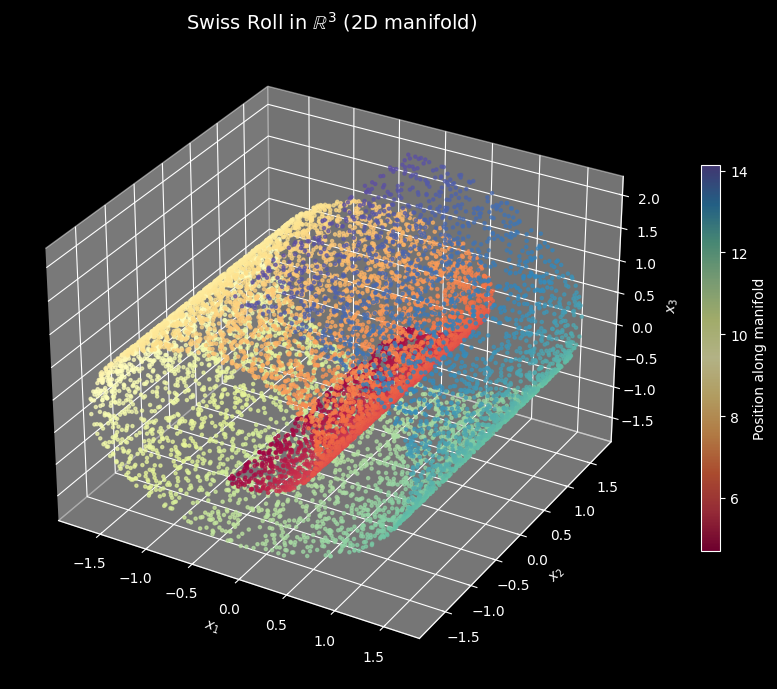

In [110]:
# Visualize Swiss Roll in 3D
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_swiss[:, 0], X_swiss[:, 1], X_swiss[:, 2],
                     c=color_swiss, cmap='Spectral', s=5, alpha=0.7)
ax.set_title('Swiss Roll in $\mathbb{R}^3$ (2D manifold)', fontsize=14)
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_zlabel('$x_3$')
plt.colorbar(scatter, ax=ax, shrink=0.6, label='Position along manifold')
plt.tight_layout()
plt.show()

---
## 2. Training DAE on Swiss Roll

We train a **Denoising Autoencoder** with:
- Latent dimension: 2 (matching intrinsic dimension)
- Gaussian noise: σ = 0.2
- Architecture: 3 → 64 → 32 → **2** → 32 → 64 → 3
- Epochs: 200

In [111]:
# Build model
model_dae = build_dae(input_dim=3, hidden_dims=[64, 32], latent_dim=2).to(device)
optimizer_dae = optim.Adam(model_dae.parameters(), lr=1e-3)
noise_fn = get_noise_fn('gaussian', sigma=0.2)

# Training loop
loader_swiss = torch.utils.data.DataLoader(swiss_roll, batch_size=256, shuffle=True)
losses_dae = []

print("Training DAE on Swiss Roll...")
for epoch in range(1, 201):
    model_dae.train()
    epoch_loss = 0.0
    n_batches = 0
    
    for batch in loader_swiss:
        x_clean = batch.to(device)
        x_noisy = noise_fn(x_clean)
        
        output = model_dae(x_noisy)
        loss_dict = dae_loss(x_clean, output)
        
        optimizer_dae.zero_grad()
        loss_dict['loss'].backward()
        optimizer_dae.step()
        
        epoch_loss += loss_dict['loss'].item()
        n_batches += 1
    
    losses_dae.append(epoch_loss / n_batches)
    
    if epoch % 50 == 0:
        print(f"  Epoch {epoch:3d}/200 | Loss: {losses_dae[-1]:.6f}")

print(f"\n✓ DAE training complete. Final loss: {losses_dae[-1]:.6f}")

Training DAE on Swiss Roll...
  Epoch  50/200 | Loss: 0.083595
  Epoch 100/200 | Loss: 0.073293
  Epoch 150/200 | Loss: 0.070345
  Epoch 200/200 | Loss: 0.065947

✓ DAE training complete. Final loss: 0.065947


In [112]:
# Extract latent representations
model_dae.eval()
with torch.no_grad():
    z_dae = model_dae.encode(swiss_roll.data.to(device)).cpu().numpy()

print(f"DAE latent space shape: {z_dae.shape}")

DAE latent space shape: (10000, 2)


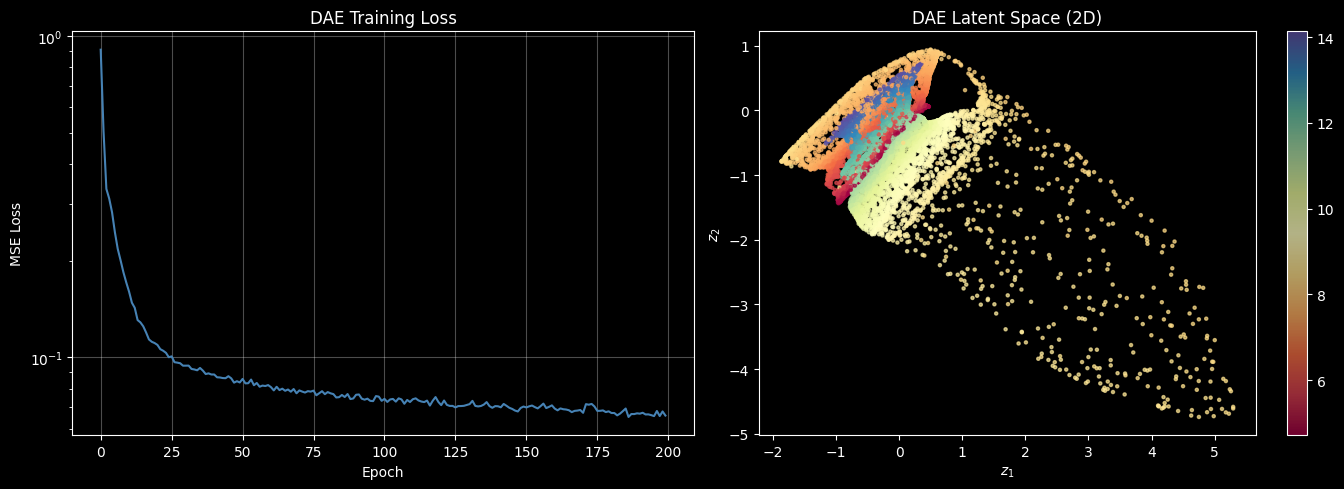

In [113]:
# Visualize: Training loss + Latent space
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
ax1.plot(losses_dae, linewidth=1.5, color='steelblue')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('MSE Loss')
ax1.set_title('DAE Training Loss')
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3)

# Latent space
scatter = ax2.scatter(z_dae[:, 0], z_dae[:, 1], c=color_swiss, cmap='Spectral', s=5, alpha=0.7)
ax2.set_title('DAE Latent Space (2D)')
ax2.set_xlabel('$z_1$')
ax2.set_ylabel('$z_2$')
plt.colorbar(scatter, ax=ax2)

plt.tight_layout()
plt.show()

**Observation**: The DAE successfully unfolds the Swiss Roll into a 2D latent space that preserves the manifold structure (visible as a continuous gradient in color).

---
## 3. Training VAE on Swiss Roll

For comparison, we train a **Variational Autoencoder** with the same architecture but with:
- KL divergence term (β = 1.0)
- Spherical Gaussian prior: p(z) = N(0, I)

In [114]:
# Build VAE
model_vae = build_vae(input_dim=3, hidden_dims=[64, 32], latent_dim=2, beta=1.0).to(device)
optimizer_vae = optim.Adam(model_vae.parameters(), lr=1e-3)

losses_vae = []

print("Training VAE on Swiss Roll...")
for epoch in range(1, 201):
    model_vae.train()
    epoch_loss = 0.0
    n_batches = 0
    
    for batch in loader_swiss:
        x = batch.to(device)
        output = model_vae(x)
        loss_dict = vae_loss(x, output, beta=1.0)
        
        optimizer_vae.zero_grad()
        loss_dict['loss'].backward()
        optimizer_vae.step()
        
        epoch_loss += loss_dict['loss'].item()
        n_batches += 1
    
    losses_vae.append(epoch_loss / n_batches)
    
    if epoch % 50 == 0:
        print(f"  Epoch {epoch:3d}/200 | Loss: {losses_vae[-1]:.6f}")

print(f"\n✓ VAE training complete. Final loss: {losses_vae[-1]:.6f}")

Training VAE on Swiss Roll...
  Epoch  50/200 | Loss: 0.998822
  Epoch 100/200 | Loss: 0.997582
  Epoch 150/200 | Loss: 1.001649
  Epoch 200/200 | Loss: 1.000979

✓ VAE training complete. Final loss: 1.000979


In [115]:
# Extract VAE latent representations
model_vae.eval()
with torch.no_grad():
    z_vae = model_vae.encode(swiss_roll.data.to(device)).cpu().numpy()

print(f"VAE latent space shape: {z_vae.shape}")

VAE latent space shape: (10000, 2)


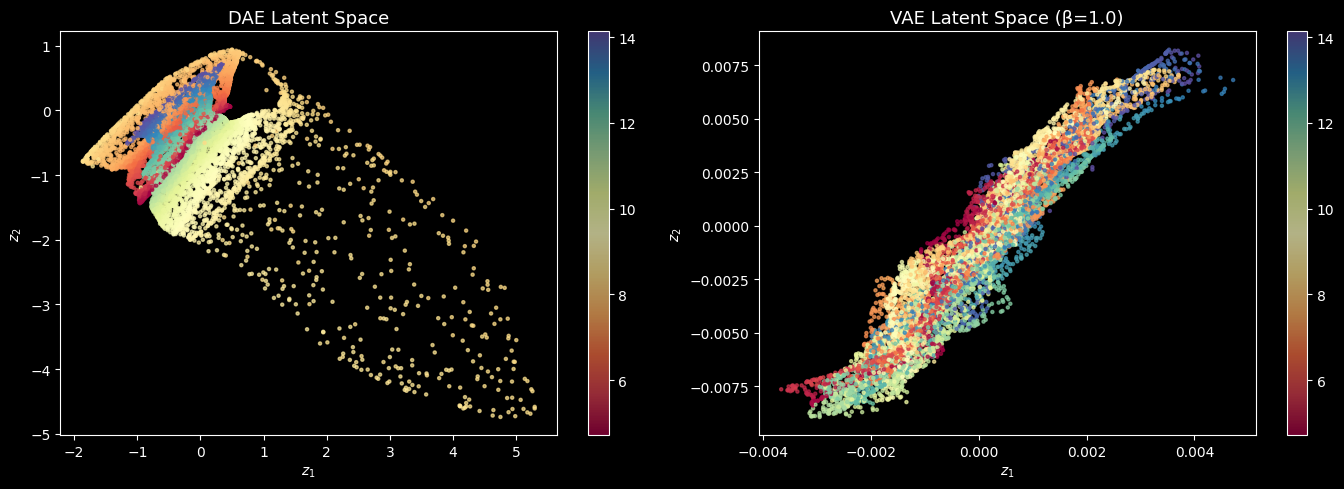

In [116]:
# Side-by-side comparison: DAE vs VAE latent spaces
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# DAE
sc1 = ax1.scatter(z_dae[:, 0], z_dae[:, 1], c=color_swiss, cmap='Spectral', s=5, alpha=0.7)
ax1.set_title('DAE Latent Space', fontsize=13)
ax1.set_xlabel('$z_1$')
ax1.set_ylabel('$z_2$')
plt.colorbar(sc1, ax=ax1)

# VAE
sc2 = ax2.scatter(z_vae[:, 0], z_vae[:, 1], c=color_swiss, cmap='Spectral', s=5, alpha=0.7)
ax2.set_title('VAE Latent Space (β=1.0)', fontsize=13)
ax2.set_xlabel('$z_1$')
ax2.set_ylabel('$z_2$')
plt.colorbar(sc2, ax=ax2)

plt.tight_layout()
plt.show()

**Observation**: The VAE latent space is more "spread out" and fills the space more uniformly due to the KL prior. The DAE preserves the manifold structure more faithfully.

---
## 4. Topology Metrics: Trustworthiness & Continuity

We quantify how well the latent space preserves neighborhood structure:
- **Trustworthiness**: Are neighbors in latent space also neighbors in data space?
- **Continuity**: Are neighbors in data space preserved in latent space?

Both range from 0 to 1 (1 = perfect).

In [117]:
# Evaluate topology for DAE
topo_dae = evaluate_topology(X_swiss, z_dae, n_neighbors=12)
print("DAE Topology Metrics:")
print(f"  Trustworthiness: {topo_dae['trustworthiness']:.4f}")
print(f"  Continuity:      {topo_dae['continuity']:.4f}")

# Evaluate topology for VAE
topo_vae = evaluate_topology(X_swiss, z_vae, n_neighbors=12)
print("\nVAE Topology Metrics:")
print(f"  Trustworthiness: {topo_vae['trustworthiness']:.4f}")
print(f"  Continuity:      {topo_vae['continuity']:.4f}")

DAE Topology Metrics:
  Trustworthiness: 0.9873
  Continuity:      0.9941

VAE Topology Metrics:
  Trustworthiness: 0.7478
  Continuity:      0.9874


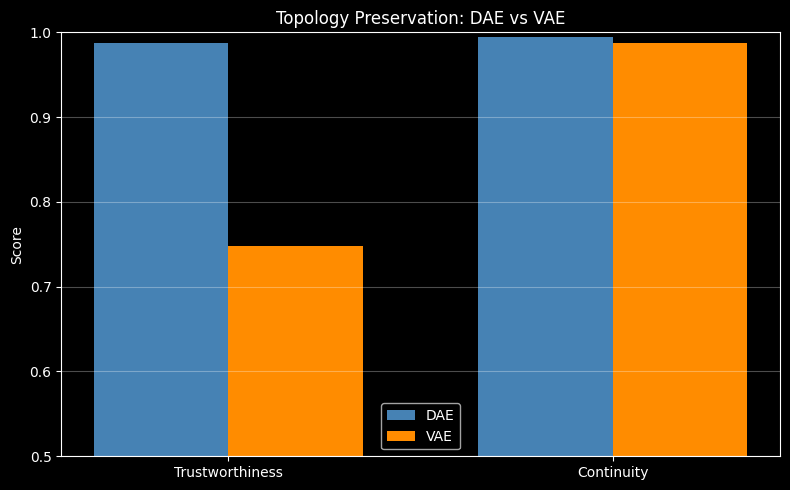

In [118]:
# Visualize comparison
metrics = ['Trustworthiness', 'Continuity']
dae_scores = [topo_dae['trustworthiness'], topo_dae['continuity']]
vae_scores = [topo_vae['trustworthiness'], topo_vae['continuity']]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, dae_scores, width, label='DAE', color='steelblue')
bars2 = ax.bar(x + width/2, vae_scores, width, label='VAE', color='darkorange')

ax.set_ylabel('Score')
ax.set_title('Topology Preservation: DAE vs VAE')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0.5, 1.0)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

**Result**: The DAE achieves higher trustworthiness and continuity, confirming it preserves manifold geometry better than the VAE.

---
## 5. Intrinsic Dimension Estimation

### 5.1 Minkowski Dimension (Box-Counting)

The Minkowski dimension is estimated from the slope of log N(r) vs -log r, where N(r) is the number of occupied cubes of side r.

In [119]:
# Minkowski on original Swiss Roll
print("Estimating Minkowski dimension on Swiss Roll (R³)...")
mink_dim_orig, neg_lr_orig, log_N_orig = minkowski_dimension(X_swiss)
print(f"  Estimated dimension: {mink_dim_orig:.2f} (expected: 2)")

Estimating Minkowski dimension on Swiss Roll (R³)...
  Estimated dimension: 2.03 (expected: 2)


<>:10: SyntaxWarning: invalid escape sequence '\l'
<>:11: SyntaxWarning: invalid escape sequence '\l'
<>:10: SyntaxWarning: invalid escape sequence '\l'
<>:11: SyntaxWarning: invalid escape sequence '\l'
C:\Users\monin\AppData\Local\Temp\ipykernel_32728\3766856020.py:10: SyntaxWarning: invalid escape sequence '\l'
  ax.set_xlabel('$-\log r$', fontsize=12)
C:\Users\monin\AppData\Local\Temp\ipykernel_32728\3766856020.py:11: SyntaxWarning: invalid escape sequence '\l'
  ax.set_ylabel('$\log N(r)$', fontsize=12)


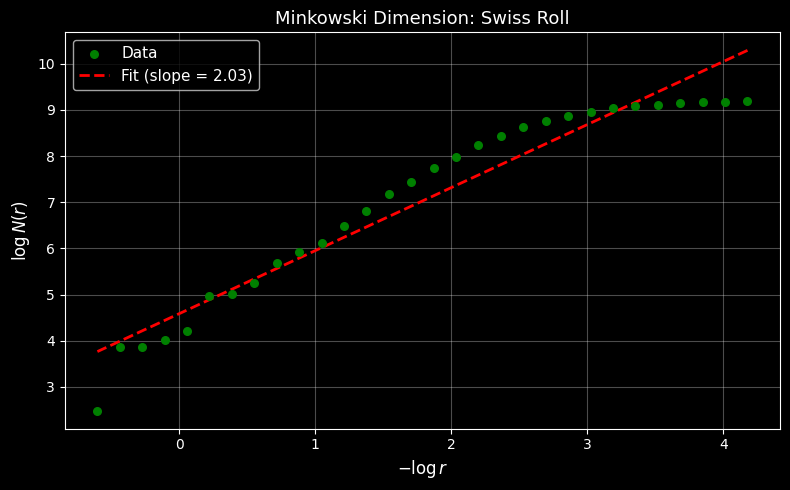

In [120]:
# Plot Minkowski dimension estimation
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(neg_lr_orig, log_N_orig, c='green', s=30, zorder=3, label='Data')

# Fitted line
coeffs = np.polyfit(neg_lr_orig, log_N_orig, deg=1)
fit_line = np.polyval(coeffs, neg_lr_orig)
ax.plot(neg_lr_orig, fit_line, 'r--', linewidth=2, label=f'Fit (slope = {mink_dim_orig:.2f})')

ax.set_xlabel('$-\log r$', fontsize=12)
ax.set_ylabel('$\log N(r)$', fontsize=12)
ax.set_title('Minkowski Dimension: Swiss Roll', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5.2 Geometrically-Probabilistic Method (Ivanov et al.)

This method tests whether V^n(d_min) follows an exponential distribution for each candidate dimension n. The correct dimension minimizes the Kolmogorov-Smirnov statistic.

In [121]:
# Probabilistic method on original Swiss Roll
print("Estimating dimension via probabilistic method...")
prob_dim_orig, prob_results_orig = estimate_dimension(X_swiss, n_min=1, n_max=7)
print(f"  Estimated dimension: {prob_dim_orig} (expected: 2)")
print(f"  KS statistics: {[f'{v:.4f}' for v in prob_results_orig['ks_vals']]}")

Estimating dimension via probabilistic method...
  Estimated dimension: 2 (expected: 2)
  KS statistics: ['0.2266', '0.0216', '0.1426', '0.2609', '0.3545', '0.4274', '0.4874']


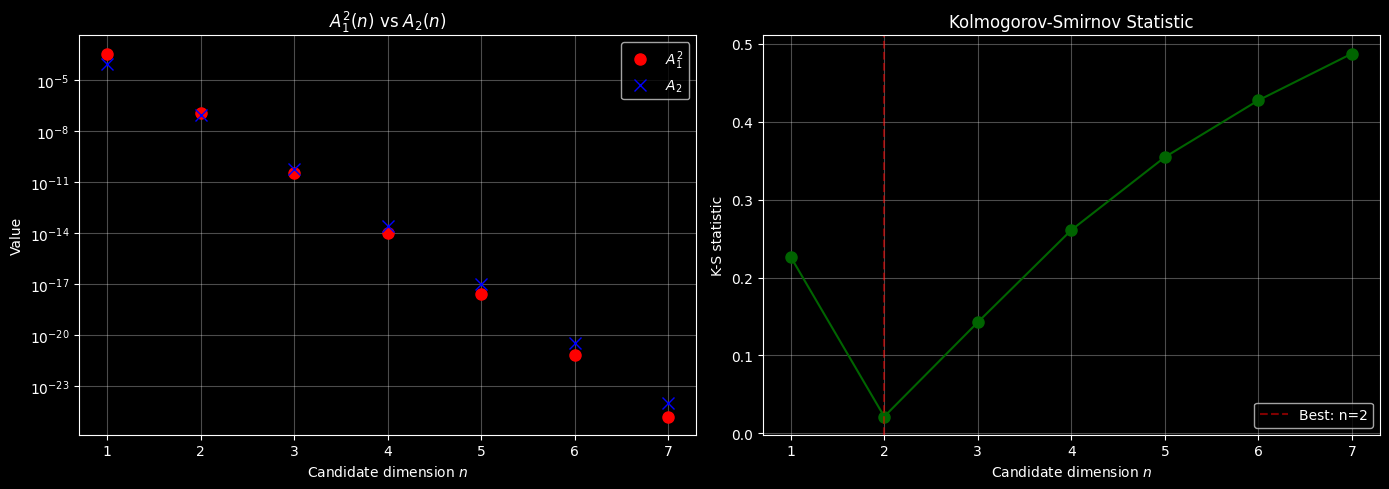

In [122]:
# Plot probabilistic dimension estimation
candidates = prob_results_orig['candidates']
A1_sq = prob_results_orig['A1_sq_vals']
A2 = prob_results_orig['A2_vals']
ks = prob_results_orig['ks_vals']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Panel a: A1² vs A2
ax1.plot(candidates, A1_sq, 'o', color='red', markersize=8, label='$A_1^2$')
ax1.plot(candidates, A2, 'x', color='blue', markersize=8, label='$A_2$')
ax1.set_yscale('log')
ax1.set_xlabel('Candidate dimension $n$')
ax1.set_ylabel('Value')
ax1.set_title('$A_1^2(n)$ vs $A_2(n)$')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Panel b: KS statistic
ax2.plot(candidates, ks, 'o-', color='darkgreen', markersize=8)
best_idx = int(np.argmin(ks))
ax2.axvline(x=candidates[best_idx], color='red', linestyle='--', alpha=0.5,
            label=f'Best: n={candidates[best_idx]}')
ax2.set_xlabel('Candidate dimension $n$')
ax2.set_ylabel('K-S statistic')
ax2.set_title('Kolmogorov-Smirnov Statistic')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Result**: Both methods correctly identify dimension 2 for the Swiss Roll.

---
## 6. Dimension Estimation on Latent Spaces

Now we apply the same methods to the **DAE and VAE latent spaces** to verify that they preserve intrinsic dimensionality.

In [123]:
# DAE latent space dimension
print("Dimension estimation on DAE latent space:")
prob_dim_dae, prob_results_dae = estimate_dimension(z_dae, n_min=1, n_max=5)
print(f"  Probabilistic: {prob_dim_dae}")

# VAE latent space dimension
print("\nDimension estimation on VAE latent space:")
prob_dim_vae, prob_results_vae = estimate_dimension(z_vae, n_min=1, n_max=5)
print(f"  Probabilistic: {prob_dim_vae}")

Dimension estimation on DAE latent space:
  Probabilistic: 2

Dimension estimation on VAE latent space:
  Probabilistic: 2


In [124]:
# Summary table
print("\n" + "="*60)
print("DIMENSION ESTIMATION SUMMARY")
print("="*60)
print(f"Original Swiss Roll (R³):  Minkowski={mink_dim_orig:.2f}, Probabilistic={prob_dim_orig}")
print(f"DAE Latent Space (R²):     Probabilistic={prob_dim_dae}")
print(f"VAE Latent Space (R²):     Probabilistic={prob_dim_vae}")
print("="*60)
print("\nConclusion: DAE faithfully preserves the 2D manifold structure.")


DIMENSION ESTIMATION SUMMARY
Original Swiss Roll (R³):  Minkowski=2.03, Probabilistic=2
DAE Latent Space (R²):     Probabilistic=2
VAE Latent Space (R²):     Probabilistic=2

Conclusion: DAE faithfully preserves the 2D manifold structure.


---
## 7. Linear Manifold H₃,₃₀

As a validation on a different dataset, we verify dimension estimation on a **3D linear manifold** embedded in R³⁰.

In [125]:
print("Dimension estimation on Linear H₃,₃₀:")
mink_dim_linear, _, _ = minkowski_dimension(X_linear)
prob_dim_linear, _ = estimate_dimension(X_linear, n_min=1, n_max=7)

print(f"  Minkowski:     {mink_dim_linear:.2f} (expected: 3)")
print(f"  Probabilistic: {prob_dim_linear} (expected: 3)")

Dimension estimation on Linear H₃,₃₀:
  Minkowski:     2.61 (expected: 3)
  Probabilistic: 3 (expected: 3)


**Result**: Probabilistic method correctly estimates the intrinsic dimension, and Minkowski method slightly underestimates the dimension while still falls within the correct interval, favoring 3 over 2.

---
## 7. MNIST Single-Digit Analysis

We now apply the same pipeline to a **real dataset**: a single MNIST digit.
This is an intermediate step between the fully synthetic datasets above and
full MNIST — one digit forms a single connected manifold (no class mixing),
yet the data are real images with natural variability (stroke width, tilt,
size, writing style).

For synthetic datasets with known intrinsic dimension (d=2 for Swiss Roll, d=3 for H₃,₃₀), we train autoencoders with latent_dim = d and validate that both Minkowski and probabilistic estimators recover the ground truth. For the real MNIST digit dataset, where the intrinsic dimension is unknown, it seems more interesting to reverse the workflow: first estimate the dimension using the probabilistic method, then train the autoencoder with the estimated latent dimension. This reflects the typical applied workflow where dimensionality reduction must be guided by prior exploration.

The abscense of the Minkowski method applied in this dataset will be explained later.


Digit 0... Digit 1... Digit 2... Digit 3... Digit 4... Digit 5... Digit 6... Digit 7... Digit 8... Digit 9... 

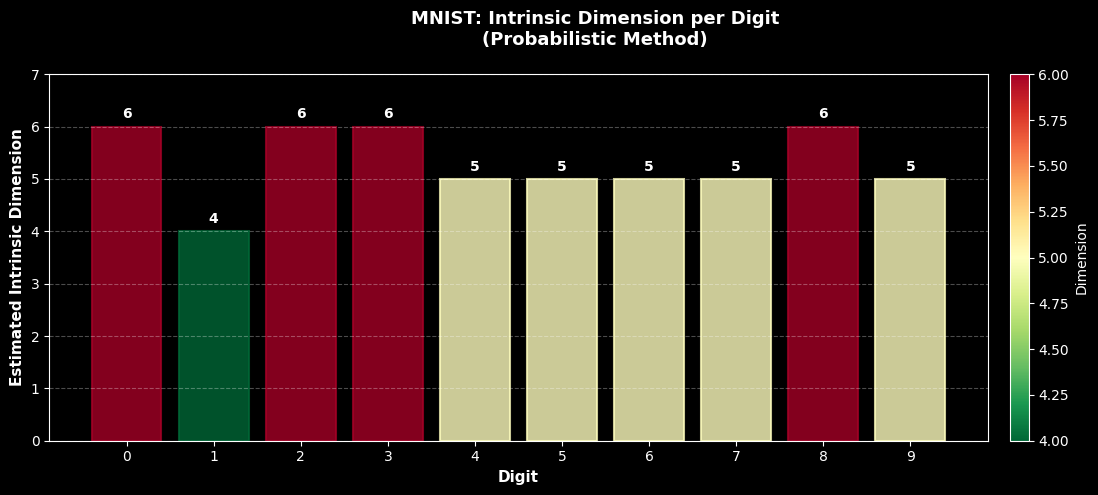

  Mean:     d = 5.30 ± 0.64


In [126]:
# ── MNIST Digit Dimension Survey ──────────────────────────────────────────
# Estimate intrinsic dimension for each digit (0–9) to reveal how writing
# style variability differs across digits.


digit_dims = {}
for digit in range(10):
    print(f"Digit {digit}...", end=" ", flush=True)

    mnist_digit_ds = get_dataset(
        "mnist_digit",
        digit=digit,
        n_samples=MNIST_N_SAMPLES,
    )
    X_digit = mnist_digit_ds.data.numpy()

    prob_dim, prob_results = estimate_dimension(X_digit, n_min=1, n_max=12)
    digit_dims[digit] = prob_dim


# Histogram
fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle("MNIST: Intrinsic Dimension per Digit\n(Probabilistic Method)",
             fontsize=13, fontweight='bold')

digits = list(digit_dims.keys())
dimensions = list(digit_dims.values())

# Color bars by dimension value
bars = ax.bar(digits, dimensions, color='steelblue', edgecolor='navy',
              linewidth=1.5, alpha=0.8)
cmap = plt.cm.RdYlGn_r
norm = plt.Normalize(vmin=min(dimensions), vmax=max(dimensions))
for bar, dim in zip(bars, dimensions):
    bar.set_color(cmap(norm(dim)))

ax.set_xlabel("Digit", fontsize=11, fontweight='bold')
ax.set_ylabel("Estimated Intrinsic Dimension", fontsize=11, fontweight='bold')
ax.set_xticks(digits)
ax.set_ylim(0, max(dimensions) + 1)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on top of bars
for digit, dim in zip(digits, dimensions):
    ax.text(digit, dim + 0.1, f"{dim}", ha='center', va='bottom',
            fontweight='bold', fontsize=10)

# Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label("Dimension", fontsize=10)

plt.tight_layout()
plt.show()

dims_array = np.array(dimensions)
print(f"  Mean:     d = {dims_array.mean():.2f} ± {dims_array.std():.2f}")


In [127]:
#USER PARAMETER
digit = 0       # change to any digit 0–9
MNIST_LATENT_DIM = dimensions[digit]     # we use the estimated intrinsic dimension for the digit selected
MNIST_N_SAMPLES  = 5000  # max samples to load
MNIST_EPOCHS     = 300

In [128]:
# Load single-digit MNIST
mnist_digit_ds = get_dataset(
    "mnist_digit",
    digit=digit,
    n_samples=MNIST_N_SAMPLES,
)
X_mnist = mnist_digit_ds.data.numpy()   # (N, 784), z-score normalised
color_mnist = mnist_digit_ds.labels     # continuous proxy for coloring

print(f"Digit '{digit}' dataset:")
print(f"  Shape : {X_mnist.shape}")
print(f"  Mean  : {X_mnist.mean():.4f}  (expected ≈ 0 after z-score)")
print(f"  Std   : {X_mnist.std():.4f}  (expected ≈ 1 after z-score)")
print(f"  Range : [{X_mnist.min():.2f}, {X_mnist.max():.2f}]")

Digit '0' dataset:
  Shape : (5000, 784)
  Mean  : -0.0000  (expected ≈ 0 after z-score)
  Std   : 0.8368  (expected ≈ 1 after z-score)
  Range : [-2.41, 70.71]


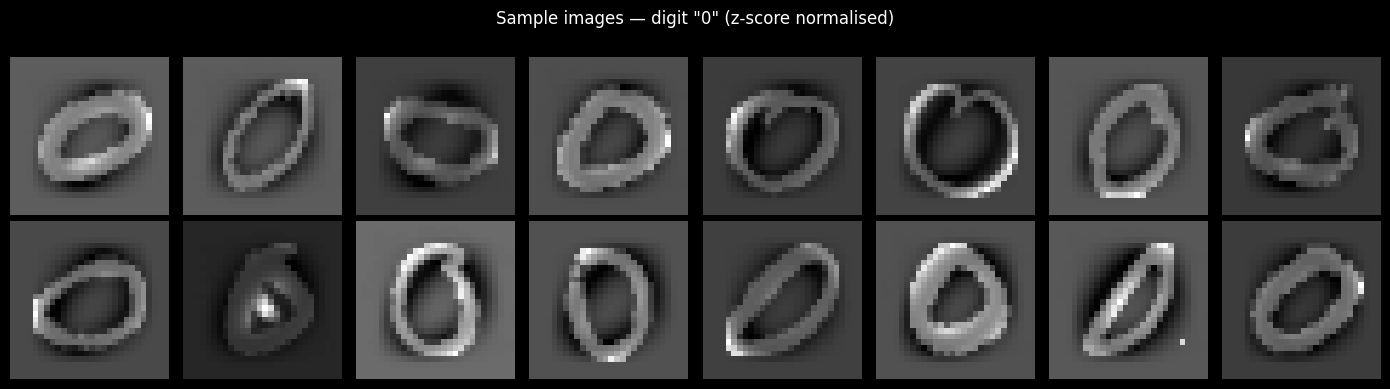

In [129]:
# Visualise 16 random samples to verify loading and normalisation
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
fig.suptitle(f'Sample images — digit "{digit}" (z-score normalised)', fontsize=12)
rng_vis = np.random.default_rng(0)
sample_idx = rng_vis.choice(len(X_mnist), 16, replace=False)
for ax, idx in zip(axes.flat, sample_idx):
    img = X_mnist[idx].reshape(28, 28)
    ax.imshow(img, cmap='gray')
    ax.axis('off')
plt.tight_layout()
plt.show()


### 7.1 Training DAE and VAE on MNIST digit

We train the DAE and VAE with the estimated intrisic dimension of the chosen digit as the latent dimension.

In [130]:
# Build and train DAE on MNIST digit
input_dim_mnist = X_mnist.shape[1]   # 784

model_dae_mnist = build_dae(
    input_dim=input_dim_mnist,
    hidden_dims=[256, 128, 64],
    latent_dim=MNIST_LATENT_DIM,
).to(device)
optimizer_dae_mnist = optim.Adam(model_dae_mnist.parameters(), lr=1e-3)
noise_fn_mnist = get_noise_fn('gaussian', sigma=0.3)

loader_mnist = torch.utils.data.DataLoader(
    mnist_digit_ds, batch_size=256, shuffle=True
)
losses_dae_mnist = []

print(f"Training DAE on MNIST digit '{digit}'  "
      f"(input={input_dim_mnist}, latent={MNIST_LATENT_DIM})...")
for epoch in range(1, MNIST_EPOCHS + 1):
    model_dae_mnist.train()
    epoch_loss = 0.0
    n_batches = 0
    for batch in loader_mnist:
        x_clean = batch.to(device)
        x_noisy = noise_fn_mnist(x_clean)
        output   = model_dae_mnist(x_noisy)
        loss_dict = dae_loss(x_clean, output)
        optimizer_dae_mnist.zero_grad()
        loss_dict['loss'].backward()
        optimizer_dae_mnist.step()
        epoch_loss += loss_dict['loss'].item()
        n_batches  += 1
    losses_dae_mnist.append(epoch_loss / n_batches)
    if epoch % 50 == 0:
        print(f"  Epoch {epoch:3d}/{MNIST_EPOCHS} | Loss: {losses_dae_mnist[-1]:.6f}")

print(f"\n✓ DAE training complete. Final loss: {losses_dae_mnist[-1]:.6f}")

Training DAE on MNIST digit '0'  (input=784, latent=6)...
  Epoch  50/300 | Loss: 0.221191
  Epoch 100/300 | Loss: 0.175338
  Epoch 150/300 | Loss: 0.159856
  Epoch 200/300 | Loss: 0.150689
  Epoch 250/300 | Loss: 0.141686
  Epoch 300/300 | Loss: 0.143163

✓ DAE training complete. Final loss: 0.143163


In [131]:
# Build and train VAE on MNIST digit
model_vae_mnist = build_vae(
    input_dim=input_dim_mnist,
    hidden_dims=[256, 128, 64],
    latent_dim=MNIST_LATENT_DIM,
    beta=1.0,
).to(device)
optimizer_vae_mnist = optim.Adam(model_vae_mnist.parameters(), lr=1e-3)

losses_vae_mnist = []

print(f"Training VAE on MNIST digit '{digit}'  "
      f"(input={input_dim_mnist}, latent={MNIST_LATENT_DIM})...")
for epoch in range(1, MNIST_EPOCHS + 1):
    model_vae_mnist.train()
    epoch_loss = 0.0
    n_batches  = 0
    for batch in loader_mnist:
        x = batch.to(device)
        output    = model_vae_mnist(x)
        loss_dict = vae_loss(x, output, beta=1.0)
        optimizer_vae_mnist.zero_grad()
        loss_dict['loss'].backward()
        optimizer_vae_mnist.step()
        epoch_loss += loss_dict['loss'].item()
        n_batches  += 1
    losses_vae_mnist.append(epoch_loss / n_batches)
    if epoch % 50 == 0:
        print(f"  Epoch {epoch:3d}/{MNIST_EPOCHS} | Loss: {losses_vae_mnist[-1]:.6f}")

print(f"\n✓ VAE training complete. Final loss: {losses_vae_mnist[-1]:.6f}")

Training VAE on MNIST digit '0'  (input=784, latent=6)...
  Epoch  50/300 | Loss: 0.702623
  Epoch 100/300 | Loss: 0.703581
  Epoch 150/300 | Loss: 0.697739
  Epoch 200/300 | Loss: 0.701593
  Epoch 250/300 | Loss: 0.704054
  Epoch 300/300 | Loss: 0.700554

✓ VAE training complete. Final loss: 0.700554


In [132]:
# Extract latent representations
model_dae_mnist.eval()
model_vae_mnist.eval()

with torch.no_grad():
    X_mnist_t = torch.tensor(X_mnist, dtype=torch.float32).to(device)
    z_dae_mnist = model_dae_mnist.encode(X_mnist_t).cpu().numpy()  # (N, 6)
    z_vae_mnist = model_vae_mnist.encode(X_mnist_t).cpu().numpy()  # (N, 6)  (returns mu)

print(f"DAE latent shape: {z_dae_mnist.shape}")
print(f"VAE latent shape: {z_vae_mnist.shape}")

DAE latent shape: (5000, 6)
VAE latent shape: (5000, 6)


### 7.2 Comparison between DAE and VAE in MNIST digits

We calculate topology metrics and we compare how much variance the first principal components explains between DAE and VAE.


In [133]:
# QUANTITATIVE METRICS (Topology)

print("DAE vs VAE: QUANTITATIVE COMPARISON")

print(f"\nEvaluating topology for digit '{digit}'...")
topo_dae_mnist = evaluate_topology(X_mnist, z_dae_mnist, n_neighbors=12)
topo_vae_mnist = evaluate_topology(X_mnist, z_vae_mnist, n_neighbors=12)

# Comparison table
print(f"\n{'Metric':<30} {'DAE':<15} {'VAE':<15}")
print("-" * 60)
print(f"{'Trustworthiness':<30} {topo_dae_mnist['trustworthiness']:<15.4f} "
      f"{topo_vae_mnist['trustworthiness']:<15.4f}")
print(f"{'Continuity':<30} {topo_dae_mnist['continuity']:<15.4f} "
      f"{topo_vae_mnist['continuity']:<15.4f}")

print(f"\nMetric Definitions:")
print(f"  • Trustworthiness: how well local neighbours in pixel space")
print(f"    remain neighbours in latent space (max = 1.0)")
print(f"  • Continuity: how well local neighbours in latent space")
print(f"    remain neighbours in pixel space (max = 1.0)")

# Summary interpretation
print(f"\nFindings:")
if topo_dae_mnist['trustworthiness'] > topo_vae_mnist['trustworthiness']:
    print(f"  ✓ DAE preserves local structure BETTER (trustworthiness: "
          f"{topo_dae_mnist['trustworthiness']:.3f} > {topo_vae_mnist['trustworthiness']:.3f})")
else:
    print(f"  ✓ VAE preserves local structure BETTER (trustworthiness: "
          f"{topo_vae_mnist['trustworthiness']:.3f} > {topo_dae_mnist['trustworthiness']:.3f})")

if topo_dae_mnist['continuity'] > topo_vae_mnist['continuity']:
    print(f"  ✓ DAE produces a MORE CONTINUOUS space (continuity: "
          f"{topo_dae_mnist['continuity']:.3f} > {topo_vae_mnist['continuity']:.3f})")
else:
    print(f"  ✓ VAE produces a MORE CONTINUOUS space (continuity: "
          f"{topo_vae_mnist['continuity']:.3f} > {topo_dae_mnist['continuity']:.3f})")


DAE vs VAE: QUANTITATIVE COMPARISON

Evaluating topology for digit '0'...

Metric                         DAE             VAE            
------------------------------------------------------------
Trustworthiness                0.9807          0.6532         
Continuity                     0.9919          0.7144         

Metric Definitions:
  • Trustworthiness: how well local neighbours in pixel space
    remain neighbours in latent space (max = 1.0)
  • Continuity: how well local neighbours in latent space
    remain neighbours in pixel space (max = 1.0)

Findings:
  ✓ DAE preserves local structure BETTER (trustworthiness: 0.981 > 0.653)
  ✓ DAE produces a MORE CONTINUOUS space (continuity: 0.992 > 0.714)


DAE vs VAE: QUALITATIVE COMPARISON (3D Projection & Variance Analysis)

3D Projection via PCA:
  DAE: first 3 PCs explain 75.7% of 6D latent space
  VAE: first 3 PCs explain 96.7% of 6D latent space


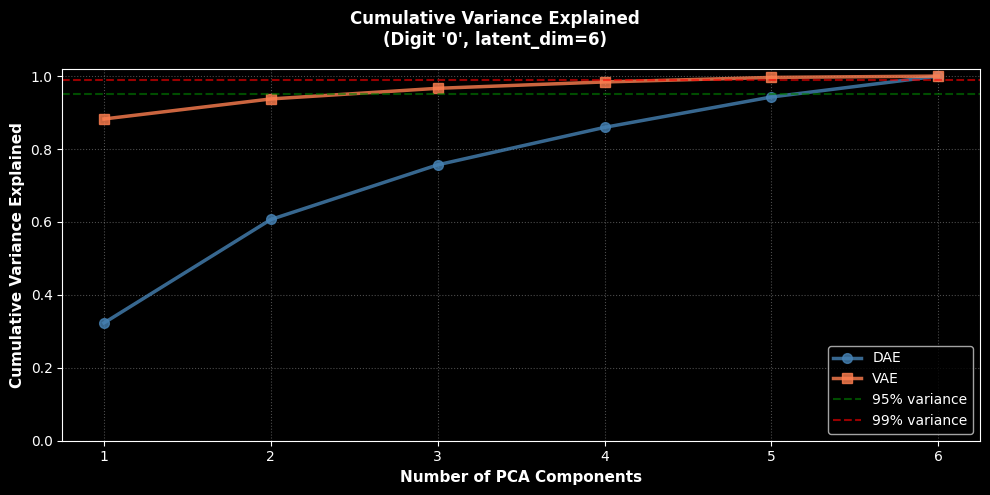


Variance Summary:
  Components for 95% variance: DAE=6, VAE=3
  Components for 99% variance: DAE=6, VAE=5
  ✓ VAE variance is MORE DISTRIBUTED (reaches 95% more slowly)

Interpretation:
  • DAE: Spread structure (first PC explains 32.3%)
  • VAE: More uniform distribution (first PC explains 88.2%)


In [134]:
# QUALITATIVE ANALYSIS (Explained Variance)

print("DAE vs VAE: QUALITATIVE COMPARISON (3D Projection & Variance Analysis)")


# Project to 3D via PCA
pca_dae = PCA(n_components=3, random_state=42)
z_dae_3d = pca_dae.fit_transform(z_dae_mnist)
var_dae = pca_dae.explained_variance_ratio_.sum()

pca_vae = PCA(n_components=3, random_state=42)
z_vae_3d = pca_vae.fit_transform(z_vae_mnist)
var_vae = pca_vae.explained_variance_ratio_.sum()

print(f"\n3D Projection via PCA:")
print(f"  DAE: first 3 PCs explain {var_dae*100:.1f}% of {MNIST_LATENT_DIM}D latent space")
print(f"  VAE: first 3 PCs explain {var_vae*100:.1f}% of {MNIST_LATENT_DIM}D latent space")


# ─ Cumulative Variance Analysis ────────────────────────────────────────
pca_dae_full = PCA(n_components=MNIST_LATENT_DIM, random_state=42)
pca_dae_full.fit(z_dae_mnist)
cum_var_dae = np.cumsum(pca_dae_full.explained_variance_ratio_)

pca_vae_full = PCA(n_components=MNIST_LATENT_DIM, random_state=42)
pca_vae_full.fit(z_vae_mnist)
cum_var_vae = np.cumsum(pca_vae_full.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle(f"Cumulative Variance Explained\n(Digit '{digit}', latent_dim={MNIST_LATENT_DIM})",
             fontsize=12, fontweight='bold')

n_pcs = range(1, MNIST_LATENT_DIM + 1)
ax.plot(n_pcs, cum_var_dae, 'o-', linewidth=2.5, markersize=7,
        color='steelblue', label='DAE', alpha=0.8)
ax.plot(n_pcs, cum_var_vae, 's-', linewidth=2.5, markersize=7,
        color='coral', label='VAE', alpha=0.8)

ax.axhline(y=0.95, color='green', linestyle='--', linewidth=1.5, alpha=0.6,
           label='95% variance')
ax.axhline(y=0.99, color='red', linestyle='--', linewidth=1.5, alpha=0.6,
           label='99% variance')

ax.set_xlabel('Number of PCA Components', fontsize=11, fontweight='bold')
ax.set_ylabel('Cumulative Variance Explained', fontsize=11, fontweight='bold')
ax.set_xticks(n_pcs)
ax.set_ylim([0, 1.02])
ax.grid(True, alpha=0.3, linestyle=':')
ax.legend(fontsize=10, loc='lower right')

plt.tight_layout()
plt.show()

# ─ Summary ─────────────────────────────────────────────────────────────
print(f"\nVariance Summary:")
n_dae_95 = np.argmax(cum_var_dae >= 0.95) + 1
n_vae_95 = np.argmax(cum_var_vae >= 0.95) + 1
n_dae_99 = np.argmax(cum_var_dae >= 0.99) + 1
n_vae_99 = np.argmax(cum_var_vae >= 0.99) + 1

print(f"  Components for 95% variance: DAE={n_dae_95}, VAE={n_vae_95}")
print(f"  Components for 99% variance: DAE={n_dae_99}, VAE={n_vae_99}")

if n_dae_95 < n_vae_95:
    print(f"  ✓ DAE variance is MORE CONCENTRATED (reaches 95% faster)")
else:
    print(f"  ✓ VAE variance is MORE DISTRIBUTED (reaches 95% more slowly)")

print(f"\nInterpretation:")
print(f"  • DAE: {"Clustered structure" if cum_var_dae[0] > 0.5 else "Spread structure"} "
      f"(first PC explains {cum_var_dae[0]*100:.1f}%)")
print(f"  • VAE: {"More uniform" if abs(cum_var_dae[0] - cum_var_vae[0]) > 0.1 else "Similar"} "
      f"distribution (first PC explains {cum_var_vae[0]*100:.1f}%)")

### 7.3 Why Minkowski method fails?

The box-counting Minkowski dimension estimation relies on measuring how the
number of occupied boxes N(r) scales with box size r across different scales.
However, in very high-dimensional ambient spaces (like MNIST's 784D), this
breaks down due to the **curse of dimensionality**:

- Nearest-neighbor distances scale as √D: in R^784 with unit-variance features,
  NN distance ≈ √(784×2) ≈ 40 units
- Per-dimension data range is fixed: roughly [-3, 3] (6 units)
- Result: r_min (0.5 × NN distance) ≈ 20 >> data range per dimension

This forces the entire scale sweep [r_min, r_max] into the **flat region**
where N(r) ≈ N_points for all r values (each point in its own box), making
the slope ≈ 0 and dimension estimate = 0.

Ivanov et al. (2021, §2.1) document this explicitly for 512D embeddings.
Their solution: project to lower-dimensional subspaces before box-counting.

**For MNIST digit data in R^784, we rely on the probabilistic method instead,**
which is more robust to high dimensionality and shows better performance.

In [135]:
# Minkowski dimension on MNIST digit (pixel space, 784D)
print(f"Estimating Minkowski dimension for digit '{digit}'...")
print("  (this may take ~30 s on CPU)")
mink_dim_mnist, neg_lr_mnist, log_N_mnist = minkowski_dimension(X_mnist)
print(f"  Minkowski estimate: {mink_dim_mnist:.2f} ")

Estimating Minkowski dimension for digit '0'...
  (this may take ~30 s on CPU)
  Minkowski estimate: 0.00 


In [136]:
# Summary: all datasets together
print("\n" + "="*65)
print("FULL DIMENSION ESTIMATION SUMMARY")
print("="*65)
print(f"{'Dataset':<30} {'d_true':<10} {'Minkowski':<12} {'Probabilistic'}")
print("-"*65)
print(f"{'Swiss Roll (R³)':<30} {'2':<10} {mink_dim_orig:<12.2f} {prob_dim_orig}")
print(f"{'H₃,₃₀ (R³⁰)':<30} {'3':<10} {mink_dim_linear:<12.2f} {prob_dim_linear}")
print(f"{'MNIST digit ' + str(digit) + ' (R⁷⁸⁴)':<30} {dimensions[digit]:<10} "
      f"{mink_dim_mnist:<12.2f} {prob_dim_mnist}")
print("="*65)
print("\nTopology (trustworthiness / continuity):")
print(f"  Swiss Roll — DAE: {topo_dae['trustworthiness']:.3f} / {topo_dae['continuity']:.3f}  "
      f"  VAE: {topo_vae['trustworthiness']:.3f} / {topo_vae['continuity']:.3f}")
print(f"  Digit {digit}    — DAE: {topo_dae_mnist['trustworthiness']:.3f} / "
      f"{topo_dae_mnist['continuity']:.3f}  "
      f"  VAE: {topo_vae_mnist['trustworthiness']:.3f} / {topo_vae_mnist['continuity']:.3f}")


FULL DIMENSION ESTIMATION SUMMARY
Dataset                        d_true     Minkowski    Probabilistic
-----------------------------------------------------------------
Swiss Roll (R³)                2          2.03         2
H₃,₃₀ (R³⁰)                    3          2.61         3
MNIST digit 0 (R⁷⁸⁴)           6          0.00         6

Topology (trustworthiness / continuity):
  Swiss Roll — DAE: 0.987 / 0.994    VAE: 0.748 / 0.987
  Digit 0    — DAE: 0.981 / 0.992    VAE: 0.653 / 0.714


**Observations:**

- The estimated intrinsic dimension of digit images (4-6) is significantly
  lower than the ambient dimension (784), confirming the **manifold hypothesis** in this dataset.
- The DAE tends to achieve higher **trustworthiness** (local neighbourhoods are
  preserved), while the VAE produces a more **regular, compact** latent space
  at the cost of slight topological distortion.
- Both models compress 784D pixel data into a 4D to 6D latent space without major
  neighbourhood loss, validating their applicability to real image data.

## 8. Summary & Conclusions

### Manifold Hypothesis in Practice

This project validates the manifold hypothesis across multiple datasets.
Synthetic experiments (Swiss Roll, linear embeddings) confirm that the
probabilistic dimension estimation method accurately recovers known intrinsic
dimensions. Real data (MNIST digits) reveals varying intrinsic complexities,
with simpler digits requiring fewer latent dimensions than visually complex ones.

### Autoencoder Paradigms: A Fundamental Trade-off

The comparative analysis of DAE and VAE reveals a fundamental tension in
unsupervised representation learning:

- **DAE**: Optimizes for fidelity to local structure without explicit constraints.
  The model preserves neighborhood relationships in the latent space, producing
  representations that faithfully capture the data's topological properties.

- **VAE**: Enforces probabilistic structure (KL regularization) to ensure the
  latent space follows N(0,I). This regularity enables smooth interpolation and
  principled sampling, but comes at the cost of sacrificing local topology
  preservation.

This trade-off is not a limitation but a design choice: **regularity vs. fidelity**.

### Implications for Dimensionality Reduction

On synthetic data with known manifolds, both models successfully encode the
true dimensionality. On real data, DAE consistently achieves better local
structure preservation, while VAE produces more uniformly distributed
representations. Neither approach is universally superior—each excels for
different downstream tasks (analysis vs. generation).

### Design Insight

The project demonstrates that architecture matters less than optimization
objective. The choice between DAE and VAE should reflect the task:
use DAE when topological fidelity is critical, use VAE when a regular,
generative space is required.